# Importing packages

In [580]:
import numpy as np
import anndata as ad
import pandas as pd
import scanpy as sc
import scipy as sp
import os
import sys
import yaml
from pathlib import Path
from collections import OrderedDict
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams
from matplotlib import colormaps
from matplotlib.lines import Line2D
from matplotlib.colors import TwoSlopeNorm
import seaborn as sns
from scipy.ndimage import gaussian_filter, binary_fill_holes, distance_transform_edt
from skimage import measure, morphology
from skimage.filters import threshold_otsu
from skimage.segmentation import find_boundaries
from shapely.geometry import Polygon
from shapely.geometry import Point
sys.path.append(os.path.abspath(".."))
rcParams['font.family'] = 'Arial'
from utils import extract_all_tumor_cores_otsu, extract_interaction
from matplotlib.colors import TwoSlopeNorm
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
import matplotlib as mpl
mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["text.color"] = "black"
mpl.rcParams["axes.labelcolor"] = "black"
mpl.rcParams["xtick.color"] = "black"
mpl.rcParams["ytick.color"] = "black"

# Call the local folders with the data

In [6]:
with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

# Set up directories
results_dir = Path(config['results_dir'])
metadata_dir = Path(config['metadata_dir'])

# Read the adata object

In [7]:
adata = ad.read(results_dir / 'adata.h5ad')

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/anndata/__init__.py:55: FutureWarning:

`anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning:

Transforming to str index.



## COZI DOTPLOT FUNCTION

In [ ]:
def cozi_dotplot_facet_by_site(
    res,
    column_name="celltype_A",
    zscore_col="zscore",
    patient_col="patient_exp",
    celltype_order=None,
    figsize=None,
    save_path=None,
    size_scale=3,
    max_dot_size=250,
    min_dot_size=8,
    vmin=None,
    vcenter=0,
    vmax=None,
    survival_data=None,
    survival_col="survival",
    tumor_site_col="tumor_site",
    tumor_site_colors=None,
    survival_ylim=None,
    show_legend=True,
    site_width_ratios=None,  # NEW: list of relative widths per site, e.g. [2, 1, 3]
):

    df = res.copy()

    df = df[[patient_col, column_name, zscore_col, "cond_percent"]].copy()

    df[patient_col] = df[patient_col].astype(str)
    df[column_name] = df[column_name].astype(str)
    df[zscore_col] = pd.to_numeric(df[zscore_col], errors="coerce")
    df["cond_percent"] = pd.to_numeric(df["cond_percent"], errors="coerce")

    # ---- celltypes ----
    if celltype_order is not None:
        celltypes = [ct for ct in celltype_order if ct in df[column_name].unique()]
    else:
        celltypes = df[column_name].drop_duplicates().tolist()

    # ---- survival + tumor site ----
    if survival_data is not None:
        surv_df = survival_data[[patient_col, survival_col, tumor_site_col]].copy()
        surv_df[patient_col] = surv_df[patient_col].astype(str)
    else:
        raise ValueError("survival_data with tumor_site is required for faceting")


    site_to_patients = (
        surv_df.groupby(tumor_site_col)
        .apply(lambda g: g.sort_values(survival_col)[patient_col].tolist())
        .to_dict()
    )

    unique_sites = list(site_to_patients.keys())
    n_sites = len(unique_sites)

    # ---- validate / build site_width_ratios ----
    if site_width_ratios is not None:
        if len(site_width_ratios) != n_sites:
            raise ValueError(
                f"site_width_ratios has {len(site_width_ratios)} values "
                f"but there are {n_sites} tumor sites: {unique_sites}"
            )
        panel_widths = list(site_width_ratios)
    else:
        # Default: proportional to number of patients in each site
        panel_widths = [len(site_to_patients[s]) for s in unique_sites]

    # ---- full grid ----
    patients_all = [p for s in unique_sites for p in site_to_patients[s]]

    full_index = pd.MultiIndex.from_product(
        [patients_all, celltypes],
        names=[patient_col, column_name]
    )

    df = (
        df.set_index([patient_col, column_name])
        .reindex(full_index)
        .reset_index()
    )

    celltype_to_y = {ct: i for i, ct in enumerate(celltypes)}
    df["y"] = df[column_name].map(celltype_to_y)

    # ---- NA handling ----
    df["is_na"] = df[zscore_col].isna()
    df["cond_percent_plot"] = df["cond_percent"].fillna(0)

    df["dot_size"] = np.sqrt(df["cond_percent_plot"].clip(lower=0)) * size_scale * 10
    df["dot_size"] = df["dot_size"].clip(lower=min_dot_size, upper=max_dot_size)
    df.loc[df["is_na"], "dot_size"] = min_dot_size

    # ---- color scaling ----
    valid_z = df.loc[~df["is_na"], zscore_col]
    if vmin is None or vmax is None:
        max_abs = np.nanmax(np.abs(valid_z)) if len(valid_z) > 0 else 1
        if not np.isfinite(max_abs) or max_abs == 0:
            max_abs = 1
        vmin, vmax = -max_abs, max_abs

    norm = TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

    # ---- figure ----
    if figsize is None:
        figsize = (4 * n_sites + 3, len(celltypes) * 0.5 + 3)

    fig = plt.figure(figsize=figsize)

    gs = GridSpec(
        nrows=2,
        ncols=n_sites + 1,
        width_ratios=panel_widths + [0.15],   # <-- custom ratios here
        height_ratios=[4, 1],
        wspace=0.15,
        hspace=0.05
    )

    cax = fig.add_subplot(gs[0, -1])
    lax = fig.add_subplot(gs[1, -1])
    lax.axis("off")

    # ---- loop over tumor sites ----
    for i, site in enumerate(unique_sites):

        site_patients = site_to_patients[site]   # already sorted by survival

        ax  = fig.add_subplot(gs[0, i])
        sax = fig.add_subplot(gs[1, i], sharex=ax)

        sub_df = df[df[patient_col].isin(site_patients)].copy()

        # local x mapping (order matches sorted site_patients)
        local_x = {p: j for j, p in enumerate(site_patients)}
        sub_df["x"] = sub_df[patient_col].map(local_x)

        # dotplot
        sc = ax.scatter(
            sub_df.loc[~sub_df["is_na"], "x"],
            sub_df.loc[~sub_df["is_na"], "y"],
            c=sub_df.loc[~sub_df["is_na"], zscore_col],
            s=sub_df.loc[~sub_df["is_na"], "dot_size"],
            cmap="coolwarm",
            norm=norm,
            edgecolor="black",
            linewidth=0.25,
        )

        ax.scatter(
            sub_df.loc[sub_df["is_na"], "x"],
            sub_df.loc[sub_df["is_na"], "y"],
            s=sub_df.loc[sub_df["is_na"], "dot_size"],
            color="darkgrey",
            edgecolor="black",
            linewidth=0.25,
        )

        ax.set_title(site, fontsize=16)

        if i == 0:
            ax.set_yticks(range(len(celltypes)))
            ax.set_yticklabels(celltypes, fontsize=14)
            ax.set_ylabel("Cell pair", fontsize=16)
        else:
            ax.set_yticks([])

        ax.set_xticks([])
        ax.invert_yaxis()
        ax.grid(True, linestyle=":", linewidth=0.4, alpha=0.5)


        # survival data
        surv_sub = surv_df[surv_df[patient_col].isin(site_patients)]
        survival_values = (
            surv_sub.set_index(patient_col)
            .reindex(site_patients)[survival_col]   # respects sorted order
        )

        sax.bar(
            range(len(site_patients)),
            survival_values,
            color="grey",
            edgecolor="black",
            linewidth=0.3,
        )

        sax.set_xticks(range(len(site_patients)))
        sax.set_xticklabels(site_patients, rotation=90, fontsize=13)

        if i == 0:
            sax.set_ylabel("Survival (months)", fontsize=10)
        else:
            sax.set_yticks([])
            sax.spines["left"].set_visible(False)

        if survival_ylim is not None:
            sax.set_ylim(survival_ylim)

        sax.spines["top"].set_visible(False)
        sax.spines["right"].set_visible(False)

    # ---- colorbar ----
    cbar = fig.colorbar(sc, cax=cax)
    cbar.set_label("Neighbor Preference z-score", fontsize=14)
    cbar.set_ticks([vmin, vcenter, vmax])
    cbar.ax.tick_params(labelsize=12)

    # ---- legend ----
    if show_legend:
        legend_vals = [5, 25, 50, 75]

        handles = []
        for val in legend_vals:
            size = np.sqrt(val) * size_scale * 3
            size = np.clip(size, min_dot_size, max_dot_size)
            handles.append(
                lax.scatter([], [], s=size, color="#B30326", edgecolor="black", linewidth=0.25)
            )

        na_handle = lax.scatter([], [], s=min_dot_size, color="darkgrey", edgecolor="black")

        lax.legend(
            handles + [na_handle],
            [f"{v}%" for v in legend_vals] + ["Low cell count"],
            title="Conditional cell percentage",
            frameon=False,
            loc="upper left",
            fontsize=12,
            title_fontsize=13,
        )

    # ---- save ----
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

In [ ]:
tumor_site_colors = {
    "Lung": "#F0F0F0",
    "Head and Neck": "#B0B0B0",
    "Extrahepatic": "#505050"
}

# Define cell category column, cell order, and cell colors

In [8]:
##get the color scheme
conditions = [
    adata.obs['cell_type'] == 'CD4+_T_cells',
    adata.obs['cell_type'] == 'CD8+_T_cells',
    adata.obs['cell_type'] == "Treg_T_cells",
    adata.obs['cell_type'] == 'NK_cells',
    adata.obs['cell_type'] == "M1_macrophages",
    adata.obs['cell_type'] == "M2_macrophages",
    adata.obs['cell_type'] == "M1_M2_macrophages",
    adata.obs['cell_type'] == "B_cells",
    adata.obs['cell_type'] == 'Plasma_cells',
    adata.obs['cell_type'] == 'DCs',
    adata.obs['cell_type'] == 'Granulocytes',
    adata.obs['cell_type'] == 'Mast_cells',
    adata.obs['cell_type'] == 'MDSCs',
    adata.obs['cell_type'] == 'Lymphatic_endothelial_cells',
    adata.obs['cell_type'] == 'Endothelial_cells',
    adata.obs['cell_type'] == 'Actin+_cells',
    adata.obs['cell_type'] == 'Tumor_cells',
    adata.obs['cell_type'] == 'Epithelial_cells',
    adata.obs['cell_type'] == 'NFC'
]

# Define the corresponding labels
labels = [
    'CD4+ T cells',
    'CD8+ T cells',
    'Treg cells',
    'NK cells',
    'M1 macrophages',
    'M2 macrophages',
    'M1/M2 macrophages',
    'B cells',
    'PCs',
    'DCs',
    'Granulocytes',
    'Mast cells',
    'MDSCs',
    'Lymphatic endothelial cells',
    'Endothelial cells',
    'Actin+ cells',
    'Tumor cells',
    'Epithelial cells',
    'NFC'
]

#using np.select
adata.obs['cell_category'] = np.select(conditions, labels, default='Other')


cell_category_color = {
    "Actin+ cells": "#AAAAFF",
    "B cells": "#FFFF00",
    "DCs": "#00FF00",
    "Endothelial cells": "#55FFFF",
    "Granulocytes": "#FF00FF",
    "Lymphatic endothelial cells": "#0055FF",
    "Mast cells": "#AA007F",
    "MDSCs": "#00007F",
    "NFC": "#A9A9A9",
    "NK cells": "#00AAFF",
    "PCs": "#FFFF7F",
    "CD4+ T cells": "#0055FF",
    "CD8+ T cells": "#FF0000",
    "Treg cells": "#AAFF7F",
    "Tumor cells": "#555555",
    "Epithelial cells": "#FFCC99",
    "M1 macrophages": "#00557F",
    "M2 macrophages": "#00AA7F",
    "M1/M2 macrophages": "#007F7F",
}

myeloid_color = {
    "DCs": "#00FF00",
    "Granulocytes": "#FF00FF",
    "Mast cells": "#AA007F",
    "MDSCs": "#00007F",
    "M1 macrophages": "#00557F",
    "M2 macrophages": "#00AA7F",
    "M1/M2 macrophages": "#007F7F",
}

lymphoid_color = {
    "B cells": "#FFFF00",
    "NK cells": "#00AAFF",
    "PCs": "#FFFF7F",
    "Treg cells": "#AAFF7F",
    "CD4+ T cells": "#0055FF",
    "CD8+ T cells": "#FF0000",  
}

#all cell types order
all_ct_order = ["Treg cells", "CD8+ T cells", "CD4+ T cells", "NK cells",  "PCs", "B cells", "DCs", 
                "Mast cells", "Granulocytes", "M1/M2 macrophages", "M1 macrophages", "M2 macrophages",  
                "MDSCs", "Lymphatic endothelial cells", "Endothelial cells", "Epithelial cells", "NFC", "Actin+ cells", "Tumor cells"]
lymphoid_order = ["Treg cells", "CD8+ T cells", "CD4+ T cells", "NK cells",  "PCs", "B cells"]
myeloid_order = ["DCs", "Mast cells", "Granulocytes", "M1/M2 macrophages", "M1 macrophages", "M2 macrophages",  "MDSCs"]

In [ ]:
#calculate cell type proportiosn per site
counts_patient = adata.obs.groupby(['patient_ID', 'cell_category']).size().unstack(fill_value=0)
#turn them to percentages
counts_patient_percentage = counts_patient.div(counts_patient.sum(axis=1), axis=0) * 100
#sort order
counts_patient_percentage = counts_patient_percentage[all_ct_order]
#select only lymphoid cells
counts_lymphoid = counts_patient_percentage[lymphoid_color.keys()]
counts_lymphoid = counts_lymphoid[lymphoid_order]
#select only myeloid cells
counts_myeloid = counts_patient_percentage[myeloid_color.keys()]
counts_myeloid = counts_myeloid[myeloid_order]

# Extract Spatial Interactions Function

In [167]:
excluded_cell_types = ["Endothelial cells", "Lymphatic endothelial cells", "NFC", "Epithelial cells", "Tumor cells", "Actin+ cells"]

In [233]:
tumor_functional_markers = [
    # Proliferation
    "KI67", "PCNA", "P16", "P16 1", "P53",
    
    # Survival / Apoptosis
    "BCL2", "CLEAVEDPARP1",
    
    # Oncogenic antigens
    "PRAME", "ERBB2",
    
    # Immune evasion / Checkpoints
    "CD274", "CD274 1", "CD276", "VISTA", "GALECTIN9", "HLAABC", "HLADR"
]

##get the color scheme
conditions = [
    adata_unified.obs['cell_type'] == 'CD4+_T_cells',
    adata_unified.obs['cell_type'] == 'CD8+_T_cells',
    adata_unified.obs['cell_type'] == "Treg_T_cells",
    adata_unified.obs['cell_type'] == 'NK_cells',
    adata_unified.obs['cell_type'] == "M1_macrophages",
    adata_unified.obs['cell_type'] == "M2_macrophages",
    adata_unified.obs['cell_type'] == "M1_M2_macrophages",
    adata_unified.obs['cell_type'] == "B_cells",
    adata_unified.obs['cell_type'] == 'Plasma_cells',
    adata_unified.obs['cell_type'] == 'DCs',
    adata_unified.obs['cell_type'] == 'Granulocytes',
    adata_unified.obs['cell_type'] == 'Mast_cells',
    adata_unified.obs['cell_type'] == 'MDSCs',
    adata_unified.obs['cell_type'] == 'Lymphatic_endothelial_cells',
    adata_unified.obs['cell_type'] == 'Endothelial_cells',
    adata_unified.obs['cell_type'] == 'Actin+_cells',
    adata_unified.obs['cell_type'] == 'Tumor_cells',
    adata_unified.obs['cell_type'] == 'Epithelial_cells',
    adata_unified.obs['cell_type'] == 'NFC'
]

# Define the corresponding labels
labels = [
    'CD4+ T cells',
    'CD8+ T cells',
    'Treg cells',
    'NK cells',
    'M1 macrophages',
    'M2 macrophages',
    'M1/M2 macrophages',
    'B cells',
    'PCs',
    'DCs',
    'Granulocytes',
    'Mast cells',
    'MDSCs',
    'Lymphatic endothelial cells',
    'Endothelial cells',
    'Actin+ cells',
    'Tumor cells',
    'Epithelial cells',
    'NFC'
]

#using np.select
adata_unified.obs['cell_category'] = np.select(conditions, labels, default='Other')


cell_category_color = {
    "Actin+ cells": "#AAAAFF",
    "B cells": "#FFFF00",
    "DCs": "#00FF00",
    "Endothelial cells": "#55FFFF",
    "Granulocytes": "#FF00FF",
    "Lymphatic endothelial cells": "#0055FF",
    "Mast cells": "#AA007F",
    "MDSCs": "#00007F",
    "NFC": "#A9A9A9",
    "NK cells": "#00AAFF",
    "PCs": "#FFFF7F",
    "CD4+ T cells": "#0055FF",
    "CD8+ T cells": "#FF0000",
    "Treg cells": "#AAFF7F",
    "Tumor cells": "#555555",
    "Epithelial cells": "#FFCC99",
    "M1 macrophages": "#00557F",
    "M2 macrophages": "#00AA7F",
    "M1/M2 macrophages": "#007F7F",
}

myeloid_color = {
    "DCs": "#00FF00",
    "Granulocytes": "#FF00FF",
    "Mast cells": "#AA007F",
    "MDSCs": "#00007F",
    "M1 macrophages": "#00557F",
    "M2 macrophages": "#00AA7F",
    "M1/M2 macrophages": "#007F7F",
}

lymphoid_color = {
    "B cells": "#FFFF00",
    "NK cells": "#00AAFF",
    "PCs": "#FFFF7F",
    "Treg cells": "#AAFF7F",
    "CD4+ T cells": "#0055FF",
    "CD8+ T cells": "#FF0000",  
}

#all cell types order
all_ct_order = ["Treg cells", "CD8+ T cells", "CD4+ T cells", "NK cells",  "PCs", "B cells", "DCs", 
                "Mast cells", "Granulocytes", "M1/M2 macrophages", "M1 macrophages", "M2 macrophages",  
                "MDSCs", "Lymphatic endothelial cells", "Endothelial cells", "Epithelial cells", "NFC", "Actin+ cells", "Tumor cells"]
lymphoid_order = ["Treg cells", "CD8+ T cells", "CD4+ T cells", "NK cells",  "PCs", "B cells"]
myeloid_order = ["DCs", "Mast cells", "Granulocytes", "M1/M2 macrophages", "M1 macrophages", "M2 macrophages",  "MDSCs"]

In [ ]:
# fig = sc.pl.matrixplot(
#      adata_select, 
#      var_names=adata_select.var_names, 
#      groupby='cell_type', 
#      cmap="coolwarm",
#      standard_scale="var",
#      use_raw=False,
#      show=False,
#      return_fig=True,
#      )

# fig.add_totals()
# axes = fig.get_axes()
# ax = axes['mainplot_ax']
# ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)  # Full rotation control
# ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)  # Font size
# group_ax = axes['group_extra_ax']
# for text in group_ax.texts:
#  text.set_fontsize(12)
#  current_pos = text.get_position()
#  text.set_position((current_pos[0] + 14, current_pos[1] +1.5 ))
# cax = axes['color_legend_ax']
# cax.set_title('scaled mean\nexpression', fontsize=10)
# cax_current_pos = cax.get_position()
# cax.set_position((cax_current_pos.x0 - 0.025, cax_current_pos.y0 - 0.08, cax_current_pos.width, cax_current_pos.height))
# fig = axes['mainplot_ax'].figure
# fig.tight_layout()
# plt.tight_layout()

In [ ]:
adata_normalized_tumor = adata_normalized[adata_normalized.obs["cell_type"] == "M2_macrophages"]
fig = sc.pl.matrixplot(
adata_normalized_tumor, 
var_names=adata_normalized_tumor.var_names, 
groupby='patient_exp', 
cmap="coolwarm",
standard_scale="group",
use_raw=False,
show=False,
return_fig=True,
)

fig.add_totals()
axes = fig.get_axes()
ax = axes['mainplot_ax']
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)  # Full rotation control
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)  # Font size
group_ax = axes['group_extra_ax']
for text in group_ax.texts:
    text.set_fontsize(12)
    current_pos = text.get_position()
    text.set_position((current_pos[0] + 14, current_pos[1] +1.5 ))
cax = axes['color_legend_ax']
cax.set_title('scaled mean\nexpression', fontsize=10)
cax_current_pos = cax.get_position()
cax.set_position((cax_current_pos.x0 - 0.025, cax_current_pos.y0 - 0.08, cax_current_pos.width, cax_current_pos.height))
fig = axes['mainplot_ax'].figure
fig.tight_layout()
plt.tight_layout()

In [ ]:
adata_select = sm.tl.spatial_count(adata_select, phenotype='cell_category', method='radius', radius=80, label='spatial_count', x_coordinate="Cell Center X", y_coordinate="Cell Center Y", imageid="patient_exp")
adata_select = sm.tl.spatial_cluster(adata_select, df_name='spatial_count', method='kmeans', k=4, label='neigh_kmeans')

In [ ]:
#Cluster cellular composition 
cluster_composition = adata_select.obs.groupby(['neigh_kmeans', 'cell_category']).size().unstack(fill_value=0)
#turn into percentages
cluster_composition = cluster_composition.div(cluster_composition.sum(axis=1), axis=0) * 100
#make it to a barplot
ax = cluster_composition.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6),
    color=[cell_category_color[c] for c in cluster_composition.columns],
    edgecolor='black', 
    linewidth=0.2
)

plt.ylabel("Cell type proportion [%]", fontsize=16)
plt.xlabel("Spatial Cluster", fontsize = 16)
plt.title(f"Cell type composition per spatial cluster in {adata_select.obs.patient_exp.unique()[0]}", fontsize=16)
#put the legend outside the plot
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc="upper left", title="Cell type")
plt.tight_layout()

sc.pl.spatial(adata_select, color='neigh_kmeans', spot_size=50, size=1.5)
unique_cats = adata_select.obs["cell_category"].unique()
plt.figure(figsize=(8,6))
plt.scatter(
    adata_select.obs["Cell Center X"],
    adata_select.obs["Cell Center Y"],
    c=adata_select.obs["cell_category"].map(cell_category_color),
    s=15,
    alpha=0.8
)
plt.gca().invert_yaxis()
plt.axis("off")
#plt title
plt.title(f'{adata_select.obs.patient_exp.unique()[0]}', fontsize=16)

for cat in unique_cats:
    plt.scatter([], [], c=cell_category_color[cat], label=cat, s=60, alpha=0.8)
plt.legend(frameon=False, markerscale=1.5, bbox_to_anchor=(1, 1),   # move legend outside plot
           loc='upper left')
plt.show()

In [ ]:
#MDSCs role in inhibiting T cells

In [ ]:
adata = sm.tl.spatial_count(adata, phenotype='cell_type', method='knn', knn=10, label='spatial_count', x_coordinate="Cell Center X", y_coordinate="Cell Center Y", imageid="patient_exp")

In [ ]:
adata = sm.tl.spatial_cluster(adata, df_name='spatial_count', method='kmeans',label='neigh_kmeans', k=7)

In [8]:
##get the color scheme
conditions = [
    adata.obs['cell_type'] == 'CD4+_T_cells',
    adata.obs['cell_type'] == 'CD8+_T_cells',
    adata.obs['cell_type'] == "Treg_T_cells",
    adata.obs['cell_type'] == 'NK_cells',
    adata.obs['cell_type'] == "M1_macrophages",
    adata.obs['cell_type'] == "M2_macrophages",
    adata.obs['cell_type'] == "M1_M2_macrophages",
    adata.obs['cell_type'] == "B_cells",
    adata.obs['cell_type'] == 'Plasma_cells',
    adata.obs['cell_type'] == 'DCs',
    adata.obs['cell_type'] == 'Granulocytes',
    adata.obs['cell_type'] == 'Mast_cells',
    adata.obs['cell_type'] == 'MDSCs',
    adata.obs['cell_type'] == 'Lymphatic_endothelial_cells',
    adata.obs['cell_type'] == 'Endothelial_cells',
    adata.obs['cell_type'] == 'Actin+_cells',
    adata.obs['cell_type'] == 'Tumor_cells',
    adata.obs['cell_type'] == 'Epithelial_cells',
    adata.obs['cell_type'] == 'NFC'
]

# Define the corresponding labels
labels = [
    'CD4+ T cells',
    'CD8+ T cells',
    'Treg cells',
    'NK cells',
    'M1 macrophages',
    'M2 macrophages',
    'M1/M2 macrophages',
    'B cells',
    'PCs',
    'DCs',
    'Granulocytes',
    'Mast cells',
    'MDSCs',
    'Lymphatic endothelial cells',
    'Endothelial cells',
    'Actin+ cells',
    'Tumor cells',
    'Epithelial cells',
    'NFC'
]

#using np.select
adata.obs['cell_category'] = np.select(conditions, labels, default='Other')


cell_category_color = {
    "Actin+ cells": "#AAAAFF",
    "B cells": "#FFFF00",
    "DCs": "#00FF00",
    "Endothelial cells": "#55FFFF",
    "Granulocytes": "#FF00FF",
    "Lymphatic endothelial cells": "#0055FF",
    "Mast cells": "#AA007F",
    "MDSCs": "#00007F",
    "NFC": "#A9A9A9",
    "NK cells": "#00AAFF",
    "PCs": "#FFFF7F",
    "CD4+ T cells": "#0055FF",
    "CD8+ T cells": "#FF0000",
    "Treg cells": "#AAFF7F",
    "Tumor cells": "#555555",
    "Epithelial cells": "#FFCC99",
    "M1 macrophages": "#00557F",
    "M2 macrophages": "#00AA7F",
    "M1/M2 macrophages": "#007F7F",
}


In [13]:
myeloid_palette = {
    "MDSCs": "#332288",
    "M2 macrophages": "#66A61E",
    "M1 macrophages": "#00557F",
    "M1/M2 macrophages": "#BBCCEE",
    "DCs": "#E69F00",
    "Granulocytes": "#B85AA6",
    "Mast cells": "#8E006A",
}
lymphoid_palette = {
    "CD8+ T cells": "#B2182B",
    "CD4+ T cells": "#EF8A62",
    "Treg T cells": "#FFCCCC",
    "NK cells": "#0096FF",
    "B cells": "#E6C84F",
    "PCs": "#F4E58A",
}
non_immune_palette = {
    "Actin+ cells": "#B39DDB",
    "Endothelial cells": "#00BFC4",
    "Lymphatic endothelial cells": "#1F78B4",
    "Epithelial cells": "#C9B29B",
}
other_palette = {
    "Tumor cells": "#44AA99",
    "NFC": "#DDDDDD",
}
full_palette = {
    **myeloid_palette,
    **lymphoid_palette,
    **non_immune_palette,
    **other_palette,
}

In [224]:
for i in adata_filtered.obs.patient_exp.unique():
    plotly_scatter(adata_filtered, phenotype="kmeans_niche", image_id=i, id_col="patient_exp", size=6, x= "Cell Center X", y="Cell Center Y")
    adata_select = adata_filtered[adata_filtered.obs["patient_exp"] == i]
    plotly_cells(adata_select, size = 6, phenotype="cell_category", color_map=full_palette)

In [4]:
adata = ad.read("/Users/jawadalaaedeen/Desktop/adata_clustered.h5ad")

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/anndata/__init__.py:55: FutureWarning:

`anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.



In [8]:
from cozipy.neighbors import knn_graph, radius_graph, delaunay_graph
from cozipy.nep_cozi import run_cozi

In [117]:
import numpy as np
from scipy.spatial import Delaunay
from scipy.sparse import coo_matrix

def delaunay_graph(coords, labels=None, remove_intra=False):
    """
    Delaunay adjacency using SciPy.
    Produces directional edges (both i->j and j->i) in COO format.

    Parameters
    ----------
    coords : np.ndarray
        Array of shape (n_cells, 2)
    labels : array-like, optional
        Cluster labels aligned with coords (length n_cells)
    remove_intra : bool
        If True, remove edges between cells of the same cluster.
    """

    tri = Delaunay(coords)
    simplices = tri.simplices

    edges = set()
    for s in simplices:
        a, b, c = s
        edges.add((a, b))
        edges.add((b, a))
        edges.add((b, c))
        edges.add((c, b))
        edges.add((a, c))
        edges.add((c, a))

    # 🔹 Remove intra-cluster edges if requested
    if remove_intra:
        if labels is None:
            raise ValueError("labels must be provided if remove_intra=True")

        labels = np.asarray(labels)
        edges = {
            (i, j) for (i, j) in edges
            if labels[i] != labels[j]
        }

    rows = [e[0] for e in edges]
    cols = [e[1] for e in edges]
    data = np.ones(len(rows), dtype=int)
    n = coords.shape[0]

    return coo_matrix((data, (rows, cols)), shape=(n, n))

In [118]:
def _encode_labels(labels):
    labels = pd.Series(labels, dtype="category")
    codes = labels.cat.codes.to_numpy()
    categories = labels.cat.categories.to_list()
    return codes, categories


def _compute_pair_counts_and_denominators(adj, labels_int, n_types):
    """
    Returns:
        counts[A, B] = total edges from A to B
        denom[A, B]  = number of cells of type A having >=1 neighbor of type B
    
    The indices fed to np.bincount are calculated using 64-bit integers 
    to prevent overflow on large numbers of cell types (n_types).
    """
    i, j = adj.row, adj.col
    labels_int = np.asarray(labels_int)

    if n_types == 0 or labels_int.size == 0:
        return np.zeros((0, 0), dtype=int), np.zeros((0, 0), dtype=int)

    # Use 64-bit integers for the calculation that previously overflowed a 32-bit integer.
    labels_int_64 = labels_int.astype(np.int64)
    n_types_64 = np.int64(n_types)

    counts = np.bincount(
        labels_int_64[i] * n_types_64 + labels_int_64[j],
        minlength=n_types_64 * n_types_64
    ).reshape(n_types, n_types)

    neigh_labels = labels_int[j]
    src_labels = labels_int[i]

    cell_has_neighbor_type = np.zeros((len(labels_int), n_types), dtype=bool)
    cell_has_neighbor_type[i, neigh_labels] = True

    denom = np.zeros((n_types, n_types), dtype=int)
    for A in range(n_types):
        maskA = (labels_int == A)
        denom[A] = cell_has_neighbor_type[maskA].sum(axis=0)

    return counts, denom


def nep_analysis(adj,
                 labels,
                 n_permutations=1000,
                 random_state=None,
                 return_df=True,
                 fixed_type=None):
    """
    NEP analysis with conditional ratios and z-scores.

    Parameters
    ----------
    STILL UNDER DEVELOPMENT IF MAKES SENSE
    fixed_type : str or int or None
        If provided, this cell type will remain fixed in permutations while
        all other cell types are shuffled.
    """
    rng = np.random.default_rng(random_state)
    labels_int, label_names = _encode_labels(labels)
    n_types = len(label_names)  # SAFER calculation of n_types

    # Ensure n_types > 0 before proceeding
    if n_types == 0:
        if return_df:
            # Return empty dataframes if there are no cell types
            idx = []
            return {
                "cond_ratio": pd.DataFrame([], index=idx, columns=idx),
                "zscore": pd.DataFrame([], index=idx, columns=idx),
            }
        else:
            return {
                "cond_ratio": np.array([]).reshape(0, 0),
                "zscore": np.array([]).reshape(0, 0),
            }

    # Pass the safely calculated n_types
    obs_counts, obs_denom = _compute_pair_counts_and_denominators(
        adj, labels_int, n_types)
    obs_norm = obs_counts / np.maximum(obs_denom, 1)

    cond_ratio = np.zeros((n_types, n_types), float)
    for A in range(n_types):
        total_A = (labels_int == A).sum()
        cond_ratio[A] = obs_denom[A] / max(total_A, 1)

    perm_norm = np.zeros((n_permutations, n_types, n_types), float)

    # convert fixed_type name -> integer index if needed
    if fixed_type is not None and isinstance(fixed_type, str):
        fixed_type = label_names.index(fixed_type)

    for k in range(n_permutations):
        if fixed_type is None:
            perm = rng.permutation(labels_int)
        else:
            # Mask cells to remain unchanged vs permuted
            fixed_mask = labels_int == fixed_type
            other_mask = ~fixed_mask

            # Copy original labels then permute only others
            perm = labels_int.copy()
            perm[other_mask] = rng.permutation(labels_int[other_mask])

        # Pass the safely calculated n_types
        c, d = _compute_pair_counts_and_denominators(adj, perm, n_types)
        perm_norm[k] = c / np.maximum(d, 1)

    expected = perm_norm.mean(axis=0)
    std = perm_norm.std(axis=0) + 1e-6
    z = (obs_norm - expected) / std

    if return_df:
        idx = label_names
        z_df = pd.DataFrame(z, index=idx, columns=idx)
        cond_df = pd.DataFrame(cond_ratio, index=idx, columns=idx)
        return {
            "cond_ratio": cond_df,
            "zscore": z_df,
        }
    else:
        return {
            "cond_ratio": cond_ratio,
            "zscore": z,
        }

In [122]:
def run_cozi(
    coords,
    labels,
    nbh_def="delaunay",
    n_permutations=100,
    random_state=None,
    fixed_type=None,
    intra_links=False,
):
    """
    Runs NEP analysis with specified neighborhood definition.
    Accepts string labels.
    """
    # build adjacency
    if nbh_def == "delaunay" and intra_links is False:
        adj = delaunay_graph(coords)
    elif nbh_def == "delaunay" and intra_links is True:
        adj = delaunay_graph(coords, labels=labels, remove_intra=True)
    else:
        raise ValueError(f"Unknown neighborhood definition: {nbh_def}")

    # run NEP
    return nep_analysis(
        adj,
        labels,
        n_permutations=n_permutations,
        random_state=random_state,
        fixed_type=fixed_type,
    )

#Different COZI approach

In [139]:
def nep_analysis(
    adj,
    labels,
    n_permutations=1000,
    random_state=None,
    return_df=True,
    fixed_type=None,
    intra_links=False,   # <-- key flag
):
    rng = np.random.default_rng(random_state)
    labels_int, label_names = _encode_labels(labels)
    n_types = len(label_names)

    if n_types == 0:
        out = {"cond_ratio": np.zeros((0,0)), "zscore": np.zeros((0,0))}
        if return_df:
            return {"cond_ratio": pd.DataFrame(), "zscore": pd.DataFrame()}
        return out

    obs_counts, obs_denom = _compute_pair_counts_and_denominators(
        adj, labels_int, n_types, remove_intra=remove_intra
    )
    obs_norm = obs_counts / np.maximum(obs_denom, 1)

    # fraction of A cells that touch at least one B
    cond_ratio = np.zeros((n_types, n_types), float)
    for A in range(n_types):
        total_A = (labels_int == A).sum()
        cond_ratio[A] = obs_denom[A] / max(total_A, 1)

    perm_norm = np.zeros((n_permutations, n_types, n_types), float)

    if fixed_type is not None and isinstance(fixed_type, str):
        fixed_type = label_names.index(fixed_type)

    for k in range(n_permutations):
        if fixed_type is None:
            perm = rng.permutation(labels_int)
        else:
            fixed_mask = labels_int == fixed_type
            other_mask = ~fixed_mask
            perm = labels_int.copy()
            perm[other_mask] = rng.permutation(labels_int[other_mask])

        # IMPORTANT: intra-removal uses *perm* labels now (consistent null)
        c, d = _compute_pair_counts_and_denominators(
            adj, perm, n_types, remove_intra=remove_intra
        )
        perm_norm[k] = c / np.maximum(d, 1)

    expected = perm_norm.mean(axis=0)
    std = perm_norm.std(axis=0) + 1e-6
    z = (obs_norm - expected) / std

    if return_df:
        idx = label_names
        return {
            "cond_ratio": pd.DataFrame(cond_ratio, index=idx, columns=idx),
            "zscore": pd.DataFrame(z, index=idx, columns=idx),
        }
    return {"cond_ratio": cond_ratio, "zscore": z}

In [140]:
def run_cozi(coords, labels, n_permutations=1000, random_state=None, fixed_type=None, remove_intra=False):
    adj = delaunay_graph(coords)
    return nep_analysis(
        adj,
        labels,
        n_permutations=n_permutations,
        random_state=random_state,
        fixed_type=fixed_type,
        remove_intra=remove_intra,
    )

## THE ACTUAL COZI

In [663]:
adata = sc.read_h5ad("/Users/jawadalaaedeen/Desktop/adata_spatial_final.h5ad")

In [186]:
import cozipy as czp 

In [664]:
import pandas as pd

all_long = []

for pt in adata.obs["patient_exp"].unique():
    adata_select = adata[adata.obs["patient_exp"] == pt].copy()

    results = czp.run_cozi(
        coords=adata_select.obs[["Cell Center X", "Cell Center Y"]].values,
        labels=adata_select.obs["cell_category"].values,
        nbh_def="delaunay",
        n_permutations=100,
        random_state=42,
            )

    # results["cond_ratio"] and results["zscore"] are DataFrames (because return_df=True by default)
    cond_df = results["cond_ratio"].copy()
    z_df = results["zscore"].copy()

    # Long format
    cond_long = (
        cond_df.stack(dropna=False)
        .rename("cond_ratio")
        .reset_index()
        .rename(columns={"level_0": "celltype_A", "level_1": "celltype_B"})
    )
    z_long = (
        z_df.stack(dropna=False)
        .rename("zscore")
        .reset_index()
        .rename(columns={"level_0": "celltype_A", "level_1": "celltype_B"})
    )

    long_df = cond_long.merge(z_long, on=["celltype_A", "celltype_B"], how="inner")

    # Conditional % (0–100)
    long_df["cond_percent"] = 100.0 * long_df["cond_ratio"]

    # Cell pair label + patient
    long_df["cell_pair"] = long_df["celltype_A"].astype(str) + "-" + long_df["celltype_B"].astype(str)
    long_df["patient_exp"] = pt

    all_long.append(long_df[["patient_exp", "celltype_A", "celltype_B", "cell_pair", "zscore", "cond_percent"]])

final_table = pd.concat(all_long, ignore_index=True)
#total number of cells and total number of tumor cells per sample
total_cells = adata.obs.groupby("patient_exp").size().reset_index(name="total_cells")
tumor_cells = adata.obs[adata.obs["cell_category"] == "Tumor cells"].groupby("patient_exp").size().reset_index(name="tumor_cells")
final_table = final_table.merge(total_cells, on="patient_exp", how="left")
final_table = final_table.merge(tumor_cells, on="patient_exp", how="left")

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_66977/3530576143.py:22: FutureWarning:

The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_66977/3530576143.py:28: FutureWarning:

The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_66977/3530576143.py:22: FutureWarning:

The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and 

In [665]:
final_table["zscore_normalized"] = final_table["zscore"] / np.sqrt(final_table["total_cells"])

In [666]:
#keep only immune cells
immune_cells = [
    "CD4+ T cells",
    "CD8+ T cells",
    "Treg T cells",
    "NK cells",
    "B cells",
    "PCs",
    "DCs",
    "Granulocytes",
    "Mast cells",
    "MDSCs",
    "M1 macrophages",
    "M2 macrophages",
    "M1/M2 macrophages"
]
immune_interactions = final_table[
    (final_table["celltype_A"].isin(immune_cells)) &
    (final_table["celltype_B"].isin(immune_cells))
].copy()

#calculate numner of celltype_A and celltype_B per patient_exp
celltype_counts = adata.obs.groupby(["patient_exp", "cell_category"]).size().reset_index(name="count")
celltype_counts = celltype_counts[celltype_counts["cell_category"].isin(immune_cells)].copy()
celltype_counts = celltype_counts.rename(columns={"count": "celltype_A_count", "cell_category": "celltype_A"})
#left join immune_interactions with celltype_counts on patient_exp and celltype_A
immune_interactions = immune_interactions.merge(celltype_counts, on=["patient_exp", "celltype_A"], how="left")
celltype_counts = celltype_counts.rename(columns={"celltype_A": "celltype_B", "celltype_A_count": "celltype_B_count"})
#left join immune_interactions with celltype_counts on patient_exp and celltype_B
immune_interactions = immune_interactions.merge(celltype_counts, on=["patient_exp", "celltype_B"], how="left")
#make patient_ID column from patient_exp
immune_interactions["patient_ID"] = immune_interactions["patient_exp"].str.replace(r"_ROI.*$", "", regex=True)
#make it NUT_ instead of NMC_
immune_interactions["patient_ID"] = immune_interactions["patient_ID"].str.replace(r"^NMC_", "NUT_", regex=True)
immune_interactions

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_66977/3462485088.py:23: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,patient_exp,celltype_A,celltype_B,cell_pair,zscore,cond_percent,total_cells,tumor_cells,zscore_normalized,celltype_A_count,celltype_B_count,patient_ID
0,NMC_1_ROI1,B cells,B cells,B cells-B cells,2.941854,38.235294,7738,3455,0.033443,34,34,NUT_1
1,NMC_1_ROI1,B cells,CD4+ T cells,B cells-CD4+ T cells,0.670279,2.941176,7738,3455,0.007620,34,40,NUT_1
2,NMC_1_ROI1,B cells,CD8+ T cells,B cells-CD8+ T cells,1.471191,17.647059,7738,3455,0.016725,34,150,NUT_1
3,NMC_1_ROI1,B cells,DCs,B cells-DCs,-0.229415,0.000000,7738,3455,-0.002608,34,2,NUT_1
4,NMC_1_ROI1,B cells,Granulocytes,B cells-Granulocytes,2.708004,2.941176,7738,3455,0.030785,34,5,NUT_1
...,...,...,...,...,...,...,...,...,...,...,...,...
3463,NMC_16_ROI19,Treg T cells,MDSCs,Treg T cells-MDSCs,0.088027,68.000000,17398,10677,0.000667,25,1967,NUT_16
3464,NMC_16_ROI19,Treg T cells,Mast cells,Treg T cells-Mast cells,-0.229415,0.000000,17398,10677,-0.001739,25,7,NUT_16
3465,NMC_16_ROI19,Treg T cells,NK cells,Treg T cells-NK cells,5.686207,4.000000,17398,10677,0.043110,25,3,NUT_16
3466,NMC_16_ROI19,Treg T cells,PCs,Treg T cells-PCs,-0.229415,0.000000,17398,10677,-0.001739,25,8,NUT_16


In [667]:
#extract from adata.obs["Survival after diagnosis of malignacy"] string the number before "months" or "Months" and convert to numeric, 
#store in new column "survival_time_months"
adata.obs["survival_time_months"] = adata.obs["Survival after diagnosis of malignacy"].str.extract(r"(\d+)\s*[mM]onths").astype(float)
survival_data = adata.obs[["patient_ID", "survival_time_months", "tumor_site"]].drop_duplicates().reset_index(drop=True)
#make it NUT_ instead of NMC_
survival_data["patient_ID"] = survival_data["patient_ID"].str.replace(r"^NMC_", "NUT_", regex=True)
survival_data["patient_ID"] = survival_data["patient_ID"].str.replace(r"^NMC_", "NUT_", regex=True)
#all of survival_data["event"] = 1 except the first NMC_1 is 0 
survival_data["event"] = 1
survival_data.loc[survival_data["patient_ID"] == "NUT_1", "event"] = 0
# survival_data = survival_data.merge(mdscs[["patient_ID", "mdscs_group"]], on="patient_ID", how="left")
survival_data["tumor_site"] = pd.Categorical(survival_data["tumor_site"], categories=["Lung", "Head and Neck", "Extrahepatic"], ordered=True)
#save survival_data to csv in results_dir 
survival_data.to_csv(os.path.join(results_dir, "survival_data.csv"), index=False)

In [251]:
immune_interactions.to_csv("/Users/jawadalaaedeen/Desktop/immune_interactions.csv", index=False)

In [684]:
#immune interaction only CD8+ T cells in either cell type A or B
cd8_interactions = immune_interactions[
    (immune_interactions["celltype_A"] == "CD8+ T cells") |
    (immune_interactions["celltype_B"] == "CD8+ T cells") |
    (immune_interactions["celltype_A"] == "CD4+ T cells") |
    (immune_interactions["celltype_B"] == "CD4+ T cells") 
].copy()

#below 45 cells in both celltype_A and celltype_B, the z_score is na
cd8_interactions_filtered = cd8_interactions.copy()

mask = (
    (cd8_interactions_filtered["celltype_A_count"] < 10) |
    (cd8_interactions_filtered["celltype_B_count"] < 10)
)

cd8_interactions_filtered.loc[mask, "zscore"] = np.nan
cd8_interactions_filtered.loc[mask, "zscore_normalized"] = np.nan


In [680]:
#focus is on MDSCs and M2 macrophages
#either celltype_A or cell_type B has to be MDSCs
mdscs_cd8 = cd8_interactions_filtered[
    (cd8_interactions_filtered["celltype_A"] == "MDSCs") |
    (cd8_interactions_filtered["celltype_B"] == "MDSCs") 
].copy()
mdscs_cd8
#calculate median per patient_ID
mdscs_cd8 = mdscs_cd8.groupby(["patient_ID", "celltype_A", "celltype_B", "cell_pair"]).agg(
    zscore = ("zscore", "median"),
    zscore_normalized=("zscore_normalized", "median"),
    cond_percent=("cond_percent", "median")
).reset_index()
mdscs_cd8
patient_order = survival_data.sort_values(["tumor_site", "survival_time_months"])["patient_ID"].tolist()
#order mdscs_cd8_interaction patient_ID accroding to patient_order
mdscs_cd8["patient_ID"] = pd.Categorical(mdscs_cd8["patient_ID"], categories=patient_order, ordered=True)
mdscs_cd8 = mdscs_cd8.sort_values("patient_ID")




missing_patients = set(patient_order) - set(mdscs_cd8["patient_ID"])
#No NUT_6 in mdscs_cd8 because no mdscs in NUT_6 so add NUT_6 with zscore and cond_percent as NA for MDSC-CD8 and vice versa
rows_to_add = []
for mp in missing_patients:
    # Direction 1: MDSCs → CD8
    rows_to_add.append({
        "patient_ID": mp,
        "celltype_A": "MDSCs",
        "celltype_B": "CD8+ T cells",
        "cell_pair": "MDSCs-CD8+ T cells",
        "zscore": np.nan,
        "zscore_normalized": np.nan,
        "cond_percent": np.nan
    })
    # Direction 2: CD8 → MDSCs
    rows_to_add.append({
        "patient_ID": mp,
        "celltype_A": "CD8+ T cells",
        "celltype_B": "MDSCs",
        "cell_pair": "CD8+ T cells-MDSCs",
        "zscore": np.nan,
        "zscore_normalized": np.nan,
        "cond_percent": np.nan
    })
    rows_to_add.append({
        "patient_ID": mp,
        "celltype_A": "MDSCs",
        "celltype_B": "CD4+ T cells",
        "cell_pair": "MDSCs-CD4+ T cells",
        "zscore": np.nan,
        "zscore_normalized": np.nan,
        "cond_percent": np.nan
    })
    rows_to_add.append({
        "patient_ID": mp,
        "celltype_A": "CD4+ T cells",
        "celltype_B": "MDSCs",
        "cell_pair": "CD4+ T cells-MDSCs",
        "zscore": np.nan,
        "zscore_normalized": np.nan,
        "cond_percent": np.nan
    })
# Add all at once
mdscs_cd8 = pd.concat([mdscs_cd8, pd.DataFrame(rows_to_add)], ignore_index=True)
mdscs_cd8["patient_ID"] = pd.Categorical(mdscs_cd8["patient_ID"], categories=patient_order, ordered=True)
mdscs_cd8["cell_pair"] = pd.Categorical(mdscs_cd8["cell_pair"], categories=["MDSCs-CD8+ T cells", "CD8+ T cells-MDSCs", "MDSCs-CD4+ T cells", "CD4+ T cells-MDSCs"], ordered=True)
mdscs_cd8 = mdscs_cd8.sort_values(["patient_ID", "cell_pair"])
mdscs_cd8

,patient_ID,celltype_A,celltype_B,cell_pair,zscore,zscore_normalized,cond_percent
0,NUT_9,MDSCs,CD8+ T cells,MDSCs-CD8+ T cells,21.942827,0.105881,11.227380
1,NUT_9,CD8+ T cells,MDSCs,CD8+ T cells-MDSCs,-0.221139,-0.003865,10.052007
3,NUT_9,MDSCs,CD4+ T cells,MDSCs-CD4+ T cells,17.377226,0.112733,11.882952
2,NUT_9,CD4+ T cells,MDSCs,CD4+ T cells-MDSCs,0.206988,0.003241,8.319804
4,NUT_2,MDSCs,CD8+ T cells,MDSCs-CD8+ T cells,6.159166,0.041574,4.787234
6,NUT_2,CD8+ T cells,MDSCs,CD8+ T cells-MDSCs,-0.462492,-0.003122,6.703911
5,NUT_2,MDSCs,CD4+ T cells,MDSCs-CD4+ T cells,2.101096,0.014182,7.446809
7,NUT_2,CD4+ T cells,MDSCs,CD4+ T cells-MDSCs,7.939986,0.053595,7.096774
11,NUT_4,MDSCs,CD8+ T cells,MDSCs-CD8+ T cells,6.602819,0.042416,20.029455
8,NUT_4,CD8+ T cells,MDSCs,CD8+ T cells-MDSCs,4.720979,0.030327,25.266904


/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_66977/2495330795.py:48: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_66977/2495330795.py:49: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



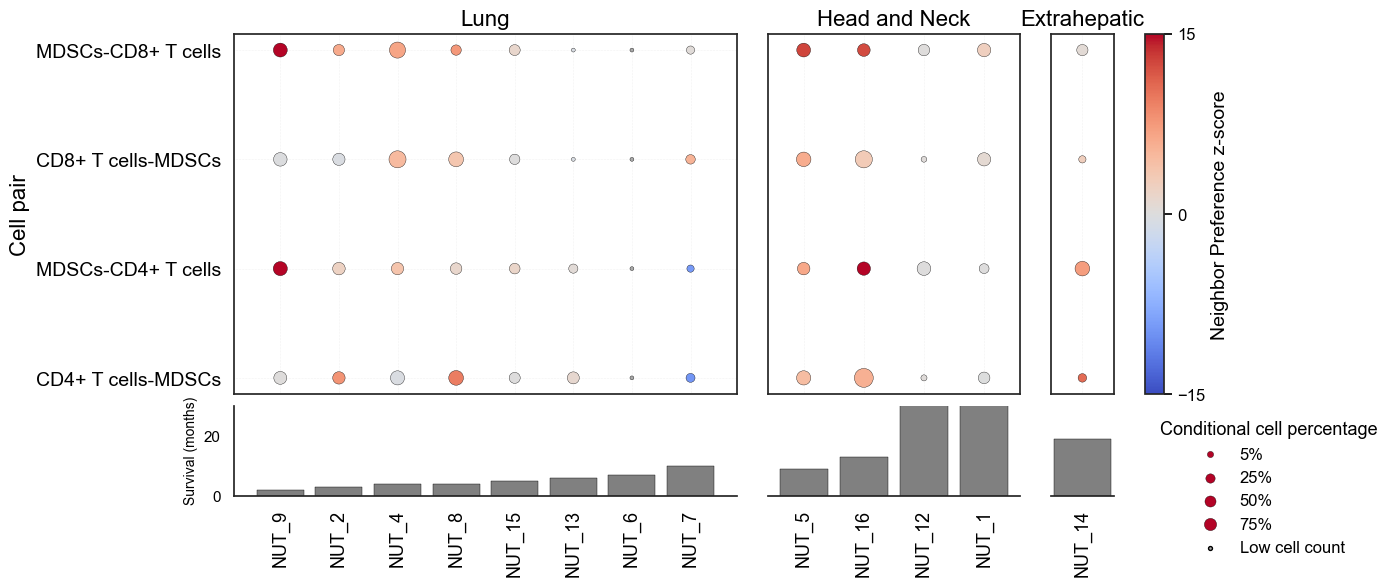

In [681]:
cozi_dotplot_facet_by_site(
    mdscs_cd8,
    column_name="cell_pair",
    zscore_col="zscore",
    patient_col="patient_ID",
    survival_data=survival_data,
    survival_col="survival_time_months",
    tumor_site_col="tumor_site",
    tumor_site_colors=tumor_site_colors,
    survival_ylim=(0, 30),
    vmin=-15,
    vmax=15,
    figsize=(12, 6),
    site_width_ratios=[4,2,0.5],
    show_legend=True,
    save_path="/Users/jawadalaaedeen/Desktop/images_for_figures/figure_4/MDSC_CD8_interaction_dotplot_by_site.pdf")

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_66977/2495330795.py:48: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_66977/2495330795.py:49: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



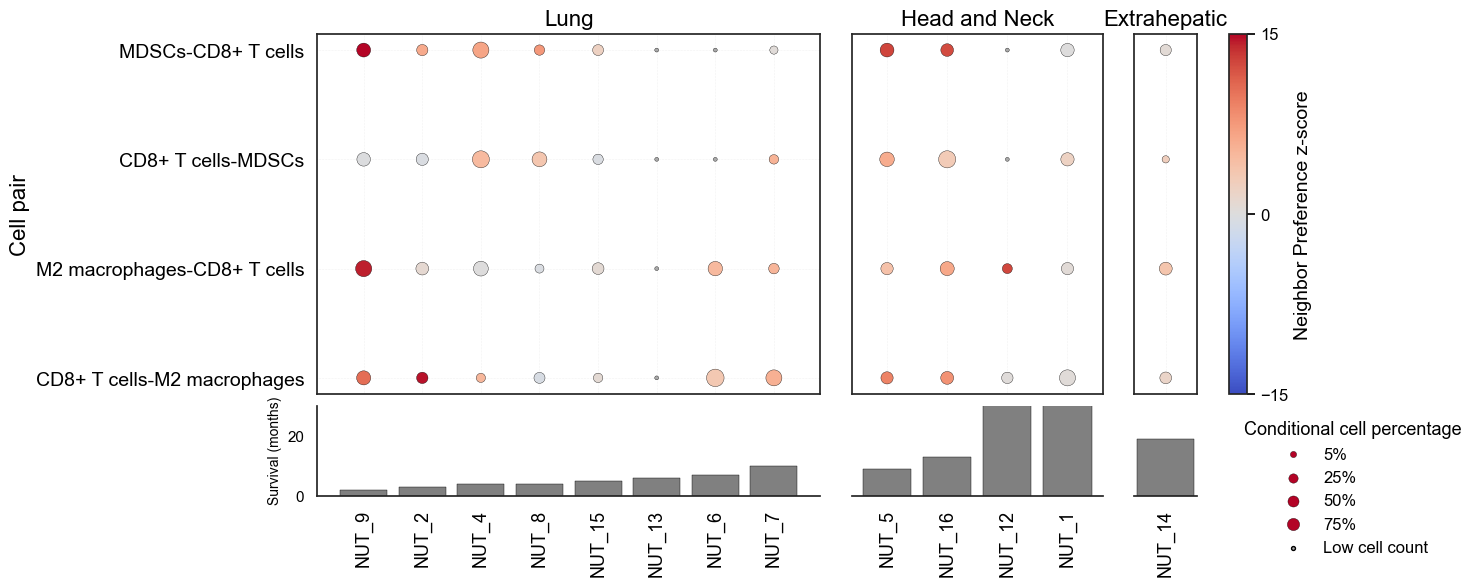

In [642]:
cozi_dotplot_facet_by_site(
    mdscs_cd8,
    column_name="cell_pair",
    zscore_col="zscore",
    patient_col="patient_ID",
    survival_data=survival_data,
    survival_col="survival_time_months",
    tumor_site_col="tumor_site",
    tumor_site_colors=tumor_site_colors,
    survival_ylim=(0, 30),
    vmin=-15,
    vmax=15,
    figsize=(12, 6),
    site_width_ratios=[4,2,0.5],
    show_legend=True,
    save_path="/Users/jawadalaaedeen/Desktop/images_for_figures/figure_4/MDSC_M2_CD8_interaction_dotplot_by_site.pdf",)

In [640]:
mdscs_cd8.to_csv(os.path.join(results_dir, "mdscs_cd8_interactions.csv"), index=False)